### Importing Libraries

In [1]:
import warnings 
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

# models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# model selection and calibration
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV

# base classes for custom estimators/baselines
from sklearn.base import clone
from sklearn.base import BaseEstimator, ClassifierMixin

import matplotlib.pyplot as plt

### Loading Data

In [2]:
df = pd.read_csv("AAPL_data.csv")

df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce', utc = True)

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_20,STD_20,Upper_Band,Lower_Band,RSI,MACD,MACD_signal,MACD_diff
0,2016-09-12 04:00:00+00:00,23.474584,24.176649,23.447141,24.112617,181171200,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-09-13 04:00:00+00:00,24.585996,24.878714,24.524250,24.686617,248704800,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-09-14 04:00:00+00:00,24.864989,25.848336,24.835259,25.560192,443554800,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-09-15 04:00:00+00:00,26.038149,26.465792,25.953535,26.429201,359934400,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-09-16 04:00:00+00:00,26.326290,26.557261,26.079309,26.280552,319547600,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['Date'] = df['Date'].dt.tz_convert(None).dt.normalize()

In [5]:
df = df.set_index('Date').sort_index()
df = df[~df.index.duplicated(keep = 'last')]

In [6]:
print(f"Loaded {len(df)} rows | {df.index.min().date()} → {df.index.max().date()}")
print(f"Index dtype: {df.index.dtype}")


Loaded 2512 rows | 2016-09-12 → 2026-09-09
Index dtype: datetime64[us]


### Feature Engineering

In [7]:
def build_features(df):
    '''build all model features from the raw OHLCV + technical columns'''
    d = df.copy()

    # Returns: stationary versions of price, better for ML than raw $
    d['ret_1d'] = d['Close'].pct_change(1)
    d['ret_5d'] = d['Close'].pct_change(5)
    d['ret_10d'] = d['Close'].pct_change(10)
    d['ret_20d'] = d['Close'].pct_change(20)

    # Volatility: short vs long, plus a ratio that spikes when the market is transitioning between calm and turbulent regimes.
    d['vol_5d'] = d['ret_1d'].rolling(5).std()
    d['vol_20d'] = d['ret_1d'].rolling(20).std()
    d['vol_ratio'] = d['vol_5d'] / (d['vol_20d'] + 1e-9)

    # Distance from moving averages: mean-reversion / trend signal
    d['px_over_ma20'] = d['Close'] / d['MA_20'] - 1
    d['px_over_ma50'] = d['Close'] / d['Close'].rolling(50).mean() - 1

    # Bolling band position and width
    d['bb_position'] = (d['Close'] - d['Lower_Band']) / (d['Upper_Band'] - d['Lower_Band'] + 1e-9)
    d['bb_width'] = (d['Upper_Band'] - d['Lower_Band']) / (d['MA_20'] + 1e-9)

    # Momentum / oscillators 
    d["rsi_norm"] = d["RSI"] / 100.0

    # MACD histogram 
    d["macd_diff_norm"] = d["MACD_diff"] / (d["Close"] + 1e-9)

    # Volume signals 
    d['vol_z'] = (d['Volume'] - d['Volume'].rolling(20).mean()) / (d['Volume'].rolling(20).std() + 1e-9)
    d['dollar_vol'] = np.log1p(d['Close'] * d['Volume']) 

    # Candle shape 
    d['hl_range'] = (d['High'] - d['Low']) / (d['Close'] + 1e-9)
    d['close_pos'] = (d['Close'] - d['Low']) / (d['High'] - d['Low'] + 1e-9)
    d['gap'] = (d['Open'] - d['Close'].shift(1)) / (d['Close'].shift(1) + 1e-9)

    # Day of week
    d['dow'] = d.index.dayofweek

    return d 

df = build_features(df)

### Target: Will price be higher in 5 trading days?

In [ ]:
# `shift(-5)` looks 5 rows INTO THE FUTURE
horizon = 5
df['future_ret'] = df['Close'].shift(-horizon) / df['Close'] - 1
df['target'] = (df['future_ret'] > 0).astype(int)

In [ ]:
feature_cols = [
    "ret_1d", "ret_5d", "ret_10d", "ret_20d",
    "vol_5d", "vol_20d", "vol_ratio",
    "px_over_ma20", "px_over_ma50",
    "bb_position", "bb_width",
    "rsi_norm", "macd_diff_norm",
    "vol_z", "dollar_vol",
    "hl_range", "close_pos", "gap",
    "dow",
]
model_df = df[feature_cols + ["target", "future_ret"]].dropna()
print(f"Modeling rows: {len(model_df)}  |  target mean (up-rate): {model_df['target'].mean():.3f}")
# Print the class balance. ~0.589 means 58.9% of 5-day windows were "up" that's your naive baseline accuracy.

Modeling rows: 2458  |  target mean (up-rate): 0.589


In [18]:
X = model_df[feature_cols].values
y = model_df['target'].values

### Evaluation

In [ ]:
# TimeSeriesSplit with gap=horizon:
#   - Each fold trains on the PAST and tests on the IMMEDIATELY FOLLOWING window.
#   - The `gap` prevents label leakage: because the target looks 5 days ahead,
#     the last 5 training rows overlap in time with the first 5 test rows. The
#     gap drops those overlapping rows.
tscv = TimeSeriesSplit(n_splits=8, gap = horizon)

def evaluate(model, X, y, tscv, name):
    """Run walk-forward validation and print per-fold metrics.

    For each fold:
      1. Clone the model (so folds don't share fitted state).
      2. Fit on the training slice.
      3. Predict probabilities on the held-out test slice.
      4. Threshold at 0.5 to get hard class predictions.
      5. Record accuracy, AUC, precision, recall, F1.
    """
    rows = []
    for fold, (tr, te) in enumerate(tscv.split(X), 1):
        m = clone(model)
        m.fit(X[tr], y[tr])
        proba = m.predict_proba(X[te])[:, 1]
        pred = (proba >= 0.5).astype(int)
        rows.append({
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "acc": accuracy_score(y[te], pred),
            "auc": roc_auc_score(y[te], proba),
            "prec": precision_score(y[te], pred, zero_division=0),
            "rec": recall_score(y[te], pred, zero_division=0),
            "f1": f1_score(y[te], pred, zero_division=0),
        })
    res = pd.DataFrame(rows)
    print(f"\n=== {name} ===")
    print(res.to_string(index=False))
    print(f"MEAN  acc={res['acc'].mean():.4f}  auc={res['auc'].mean():.4f}  "
          f"f1={res['f1'].mean():.4f}")
    return res


### Baseline

In [ ]:
# Any model you build MUST beat these. If it doesn't, you have no edge.

class MajorityBaseline:
    '''Always predicts the majority class in the training set'''
    def fit(self, X, y):
        self.pred_ = int(round(y.mean()))
        return self
    def predict(self, X) :
        return np.full(len(X), self.pred_)
    def predict_proba(self, X):
        p = np.full((len(X), 2), 1 - self.pred_, dtype = float)
        p[:, self.pred_] = self.pred_ 

class MomentumBaseline:
    '''Predicts 'up' if the 20 day return was positive'''
    def __init__(self, col_idx):
        self.col_idx = col_idx
    def fit(self, X, y):
        return self 
    def predict(self, X):
        return (X[:, self.col_idx] > 0).astype(int)
    def predict_proba(self, X):
        p = self.predict(X).astype(float)
        return np.column_stack([1-p, p])

class SklearnBaseline(BaseEstimator, ClassifierMixin):
    """Wraps the baselines above in sklearn's estimator interface so they work with `clone()`, `GridSearchCV`, and `evaluate()`."""
    def __init__(self, kind = 'majority', col_idx = 0):
        self.kind = kind 
        self.col_idx = col_idx 
    def fit(self, X,y):
        if self.kind == 'majority':
            self.pred_ = int(round(y.mean()))
        return self 
    def predict(self, X):
        if self.kind == 'majority':
            return np.full(len(X), self.pred_)
        return (X[:, self.col_idx] > 0).astype(int)
    def predict_proba(self, X):
        if self.kind == 'majority':
            p = np.full((len(X),2), 1 - self.pred_, dtype = float)
            p[:, self.pred_] = self.pred_
            return p 
        p = self.predict(X).astype(float)
        return np.column_stack([1 - p, p])

# Run both baselines through the same walk-forward harness as the real models.
evaluate(SklearnBaseline(kind="majority"), X, y, tscv, "Majority class")

# Look up which column index holds ret_20d so the momentum baseline can find it.
ret20_idx = feature_cols.index("ret_20d")
evaluate(SklearnBaseline(kind="momentum", col_idx=ret20_idx), X, y, tscv,
         "Momentum (20d return > 0)")



=== Majority class ===
 fold  n_train  n_test      acc  auc     prec  rec       f1
    1      269     273 0.556777  0.5 0.556777  1.0 0.715294
    2      542     273 0.710623  0.5 0.710623  1.0 0.830835
    3      815     273 0.597070  0.5 0.597070  1.0 0.747706
    4     1088     273 0.556777  0.5 0.556777  1.0 0.715294
    5     1361     273 0.556777  0.5 0.556777  1.0 0.715294
    6     1634     273 0.560440  0.5 0.560440  1.0 0.718310
    7     1907     273 0.523810  0.5 0.523810  1.0 0.687500
    8     2180     273 0.582418  0.5 0.582418  1.0 0.736111
MEAN  acc=0.5806  auc=0.5000  f1=0.7333

=== Momentum (20d return > 0) ===
 fold  n_train  n_test      acc      auc     prec      rec       f1
    1      269     273 0.512821 0.509406 0.565517 0.539474 0.552189
    2      542     273 0.677656 0.529329 0.724576 0.881443 0.795349
    3      815     273 0.564103 0.531511 0.619565 0.699387 0.657061
    4     1088     273 0.538462 0.520634 0.572222 0.677632 0.620482
    5     1361     27

,fold,n_train,n_test,acc,auc,prec,rec,f1
0,1,269,273,0.512821,0.509406,0.565517,0.539474,0.552189
1,2,542,273,0.677656,0.529329,0.724576,0.881443,0.795349
2,3,815,273,0.564103,0.531511,0.619565,0.699387,0.657061
3,4,1088,273,0.538462,0.520634,0.572222,0.677632,0.620482
4,5,1361,273,0.578755,0.577887,0.631206,0.585526,0.607509
5,6,1634,273,0.531136,0.520588,0.577640,0.607843,0.592357
6,7,1907,273,0.417582,0.413287,0.450000,0.503497,0.475248
7,8,2180,273,0.534799,0.510013,0.589888,0.660377,0.623145


### Models and Hyperparameter Tuning

In [ ]:
# Models

# Three families, deliberately different in bias/variance profile:
#   - LogisticRegression: high bias, low variance, interpretable.
#   - RandomForest:       low bias, moderate variance, robust to outliers.
#   - GradientBoosting:   low bias, can overfit, best on structured tabular data.

models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=20,
        class_weight='balanced', random_state=1234, n_jobs=-1,
    ),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8, 
        random_state=1234
    )
}

results = {}
for name, model in models.items():
    results[name] = evaluate(model, X, y, tscv, name)


=== LogisticRegression ===
 fold  n_train  n_test      acc      auc     prec      rec       f1
    1      269     273 0.454212 0.509678 0.515152 0.335526 0.406375
    2      542     273 0.388278 0.458502 0.645161 0.309278 0.418118
    3      815     273 0.509158 0.584607 0.754386 0.263804 0.390909
    4     1088     273 0.439560 0.461614 0.444444 0.026316 0.049689
    5     1361     273 0.516484 0.624728 0.651515 0.282895 0.394495
    6     1634     273 0.509158 0.546569 0.633803 0.294118 0.401786
    7     1907     273 0.483516 0.480204 0.513514 0.265734 0.350230
    8     2180     273 0.472527 0.529957 0.615385 0.251572 0.357143
MEAN  acc=0.4716  auc=0.5245  f1=0.3461

=== RandomForestClassifier ===
 fold  n_train  n_test      acc      auc     prec      rec       f1
    1      269     273 0.424908 0.404252 0.484472 0.513158 0.498403
    2      542     273 0.505495 0.597547 0.747899 0.458763 0.568690
    3      815     273 0.538462 0.524317 0.613497 0.613497 0.613497
    4     1088  

In [ ]:
# Hyperparameter tuning 

# We tune on ROC-AUC (threshold-independent) rather than accuracy, because
# accuracy rewards the majority class and hides poor ranking.

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [10, 20, 40],
    'max_features': ['sqrt', 0.5],
}

gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=1234, n_jobs=-1),
    param_grid,
    cv = TimeSeriesSplit(n_splits=4, gap = horizon),
    scoring='roc_auc',
    n_jobs=-1
)

gs.fit(X, y)
print("Best params:", gs.best_params_)
print(f"Best CV AUC: {gs.best_score_:.4f}")

# Evaluate the tuned model with walk-forward
evaluate(gs.best_estimator_, X, y, tscv, "RandomForest (tuned)")

Best params: {'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 200}
Best CV AUC: 0.4933

=== RandomForest (tuned) ===
 fold  n_train  n_test      acc      auc     prec      rec       f1
    1      269     273 0.399267 0.402893 0.459459 0.447368 0.453333
    2      542     273 0.498168 0.580843 0.743590 0.448454 0.559486
    3      815     273 0.494505 0.510820 0.578616 0.564417 0.571429
    4     1088     273 0.560440 0.583732 0.633333 0.500000 0.558824
    5     1361     273 0.534799 0.547086 0.616822 0.434211 0.509653
    6     1634     273 0.487179 0.438780 0.535519 0.640523 0.583333
    7     1907     273 0.534799 0.516138 0.565574 0.482517 0.520755
    8     2180     273 0.461538 0.497904 0.550000 0.415094 0.473118
MEAN  acc=0.4963  auc=0.5098  f1=0.5287


,fold,n_train,n_test,acc,auc,prec,rec,f1
0,1,269,273,0.399267,0.402893,0.459459,0.447368,0.453333
1,2,542,273,0.498168,0.580843,0.743590,0.448454,0.559486
2,3,815,273,0.494505,0.510820,0.578616,0.564417,0.571429
3,4,1088,273,0.560440,0.583732,0.633333,0.500000,0.558824
4,5,1361,273,0.534799,0.547086,0.616822,0.434211,0.509653
5,6,1634,273,0.487179,0.438780,0.535519,0.640523,0.583333
6,7,1907,273,0.534799,0.516138,0.565574,0.482517,0.520755
7,8,2180,273,0.461538,0.497904,0.550000,0.415094,0.473118


### Calibration and Threshold Analysis

In [ ]:
# Raw tree probabilities are often miscalibrated (pushed toward 0 and 1).
# `CalibratedClassifierCV` with isotonic regression learns a monotone mapping
# so that "predicted 0.60" actually means "60% of the time this is up."

# Use the LAST fold as an honest held-out test set for this demo.
tr_idx, te_idx = list(tscv.split(X))[-1]
X_tr, X_te, y_tr, y_te = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]

base = gs.best_estimator_
calibrated = CalibratedClassifierCV(base, method='isotonic', cv = 3)
calibrated.fit(X_tr, y_tr)

proba = calibrated.predict_proba(X_te)[:, 1]

print(f"Held-out fold: n={len(y_te)}, base up-rate={y_te.mean():.3f}")
print(f"AUC: {roc_auc_score(y_te, proba):.4f}")

# Sweep decision thresholds. Higher threshold = fewer, higher-conviction trades.
print("\nThreshold sweep (precision = how often we're right when we say 'up'):")
print(f"{'thresh':>8} {'n_trades':>9} {'precision':>10} {'recall':>8} {'f1':>7}")
for t in np.arange(0.45, 0.71, 0.05):
    pred = (proba >= t).astype(int)
    n = pred.sum()
    if n == 0:
        continue
    print(f"{t:>8.2f} {n:>9d} {precision_score(y_te, pred, zero_division=0):>10.3f} "
          f"{recall_score(y_te, pred, zero_division=0):>8.3f} "
          f"{f1_score(y_te, pred, zero_division=0):>7.3f}")



Held-out fold: n=273, base up-rate=0.582
AUC: 0.4865

Threshold sweep (precision = how often we're right when we say 'up'):
  thresh  n_trades  precision   recall      f1
    0.45       241      0.614    0.931   0.740
    0.50       214      0.603    0.811   0.692
    0.55        37      0.514    0.119   0.194
    0.60         1      1.000    0.006   0.013
    0.65         1      1.000    0.006   0.013


### Feature Importance

In [16]:
final_rf = gs.best_estimator_
final_rf.fit(X, y)
importances = pd.Series(final_rf.feature_importances_, index = feature_cols)
print(importances.sort_values(ascending=False).to_string())


dollar_vol        0.110520
bb_width          0.081266
ret_10d           0.081081
vol_20d           0.077778
ret_20d           0.071395
vol_ratio         0.057499
rsi_norm          0.057314
px_over_ma20      0.057139
px_over_ma50      0.056360
ret_5d            0.050359
vol_5d            0.047728
macd_diff_norm    0.046322
bb_position       0.046198
close_pos         0.039533
vol_z             0.033270
hl_range          0.029854
gap               0.025269
ret_1d            0.022959
dow               0.008156


### Backtest

In [ ]:
# Compare the model's signal to plain buy-and-hold on the SAME test window.

thresh = 0.55 
signals = (proba >= thresh).astype(int)

# Pull the actual 5-day forward return for each test day so we can compute
# the strategy's realized P&L.
fold_future_ret = model_df['future_ret'].iloc[te_idx].values 

# Strategy: capture future_ret only on days we said "up"; flat otherwise.
# (This is an *approximation* — it assumes you enter at today's close and
#  exit exactly 5 days later, ignoring overlaps and transaction costs.)
strategy_ret = signals * fold_future_ret 
bh_ret = fold_future_ret 

def sharpe(r, periods = 252/horizon):
      """Annualized Sharpe ratio for a series of H-day returns."""
      return np.sqrt(periods) * r.mean() / (r.std() + 1e-9)

print(f"Threshold: {thresh}")
print(f"Trades taken: {signals.sum()} / {len(signals)}")
print(f"Strategy  mean 5d ret: {strategy_ret.mean():+.4f}  "
      f"Sharpe: {sharpe(strategy_ret):+.2f}")
print(f"Buy&Hold  mean 5d ret: {bh_ret.mean():+.4f}  "
      f"Sharpe: {sharpe(bh_ret):+.2f}")
print(f"Strategy hit-rate: {(strategy_ret[signals==1] > 0).mean():.3f}")


Threshold: 0.55
Trades taken: 37 / 273
Strategy  mean 5d ret: +0.0003  Sharpe: +0.15
Buy&Hold  mean 5d ret: +0.0088  Sharpe: +1.63
Strategy hit-rate: 0.514


              precision    recall  f1-score   support

        Down       0.49      0.25      0.34       114
          Up       0.60      0.81      0.69       159

    accuracy                           0.58       273
   macro avg       0.55      0.53      0.51       273
weighted avg       0.56      0.58      0.54       273



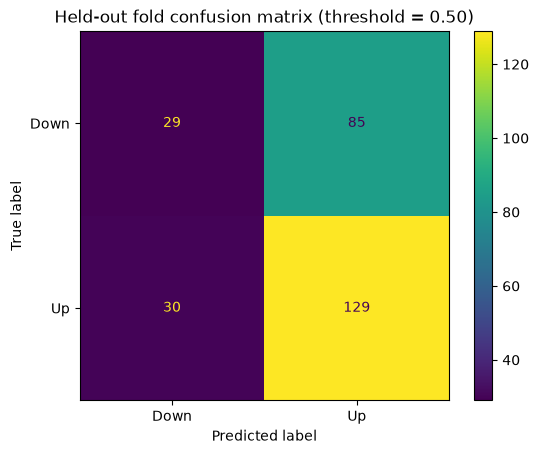

In [19]:
# Confusion matrix + classification report on the held-out fold ---
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred_05 = (proba >= 0.5).astype(int)
print(classification_report(y_te, pred_05, target_names=["Down", "Up"]))
ConfusionMatrixDisplay.from_predictions(y_te, pred_05, display_labels=["Down", "Up"])
plt.title("Held-out fold confusion matrix (threshold = 0.50)")
plt.show()

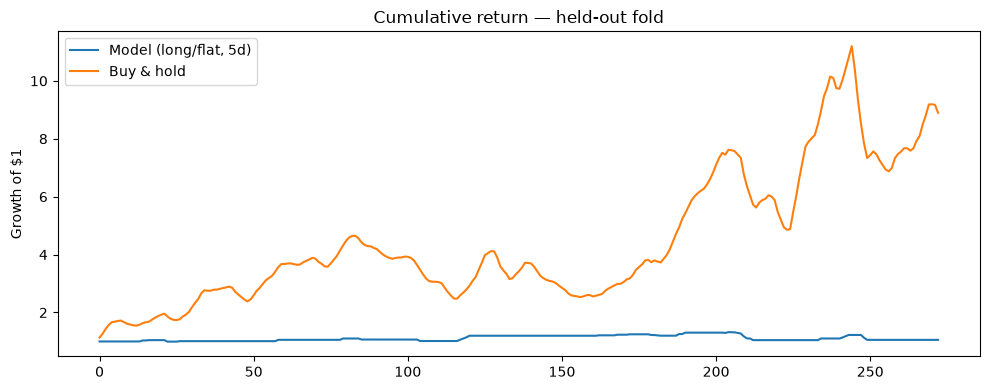

In [20]:
# Equity curve vs buy-and-hold ---
cum_strategy = (1 + strategy_ret).cumprod()
cum_bh = (1 + bh_ret).cumprod()

plt.figure(figsize=(10, 4))
plt.plot(cum_strategy, label="Model (long/flat, 5d)")
plt.plot(cum_bh, label="Buy & hold")
plt.legend()
plt.title("Cumulative return — held-out fold")
plt.ylabel("Growth of $1")
plt.tight_layout()
plt.show()